In [18]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
from pathlib import Path
import pandas as pd
from typing import List, Dict
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from functools import lru_cache


from rdkit import Chem
from rdkit.Chem import Descriptors

from prob.interactions.interaction_data import load_ident_activity_mapping
from prob.prob_plots import plot_dist_with_log, plot_transformation_mapping
from prob.paths_and_io import get_project_root, get_data_dir

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Paths

In [2]:
_ROOT = get_project_root()
print(f"Project root: {_ROOT}")
_DATA_DIR = get_data_dir(prob=False)
print(f"Data directory: {_DATA_DIR}")

interactions_dir  = _DATA_DIR / "plip_kinodata3d" / "processed"
mws_dir          = _DATA_DIR / "probing/helpers/mw"
intr_helper_dir   = _DATA_DIR / "probing/helpers/intr_scores"
targets_dir       = _DATA_DIR / "probing/targets"
figures_dir       = targets_dir / "figures"

Project root: /Users/fatemeh/Thesis/kinodata-3D-affinity-prediction
Data directory: /Users/fatemeh/Thesis/kinodata-3D-affinity-prediction/data


# Loading Data

In [3]:
# interaction_names = ["halogen_bonds", "hydrogen_bonds", "hydrophobic_interactions", "pi_stacking", "salt_bridges"]

mapping = load_ident_activity_mapping()
hydrogen_bonds_df = pd.read_csv(interactions_dir / "hydrogen_bonds.csv")


### Continuous Intercation Score

The final score will be calculated as:
$$
\displaystyle\sum_{\text{residues}}{\text{residue attribution score} × \frac{\displaystyle\sum_{\text{bonds}}{\text{bond score}}}{\text{total number of bonds the ligand CAN form}}}
$$

Instead of using "the total numbers of bonds a molecule can form", I'll be using **MW** as a proxy. <br>
The reason for that is to find a standard weight (after pre-processing) to use for all type of bonds later on, rather than having to calculate this coefficient for each bond separately. MW is considered as an acceptable proxy, because the bigger the molecule, it is more likely to form more bonds.


The residue attribution scores 

### Discrete Interaction Score

This would be just the total number of interactions, factored by $MW^{-1}$

$MW$ is to account for the total number of bonds a molecule can form. Because the bigger the molecule, the more the number of bonds it can have

# MW
Statistical Analysis and Normalizations in mw notebook

In [5]:
mws = pd.read_csv(mws_dir / "mws.csv")
mws.head(2)

,smiles,ident,y_processed,activity_id,mw,mw_exp
0,Nc1ncnc2c1c(-c1cccc(Oc3ccccc3)c1)cn2C1CCCC1,0,5.148742,32335,370.456,1.924723
1,Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)cn2[C@@H]1CCC...,17,6.000000,40693,386.455,1.965846


In [4]:
mws.describe()

,ident,y_processed,activity_id,mw,mw_exp
count,119522.000000,119522.000000,1.195220e+05,119522.000000,119522.000000
mean,59839.345409,7.157915,1.447413e+07,440.439277,2.087174
std,34556.690899,1.285625,6.741092e+06,92.278931,0.219317
min,0.000000,1.019997,3.233500e+04,76.124000,0.872491
25%,29917.250000,6.251812,1.101915e+07,378.404000,1.945261
50%,59859.500000,7.275724,1.690582e+07,438.532000,2.094116
75%,89748.750000,8.096910,1.779593e+07,498.930500,2.233675
max,119712.000000,14.000000,2.497011e+07,1861.731000,4.314778


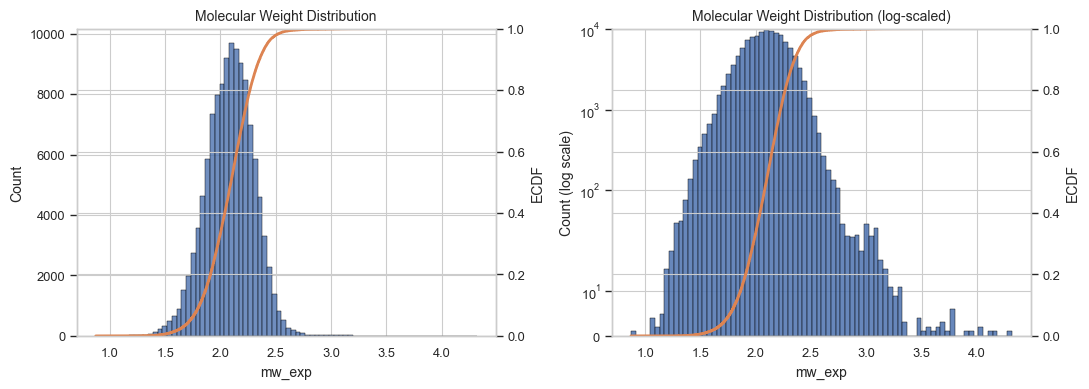

In [8]:
plot_dist_with_log(mws, "mw_exp", title="Molecular Weight Distribution", show_ecdf=True)

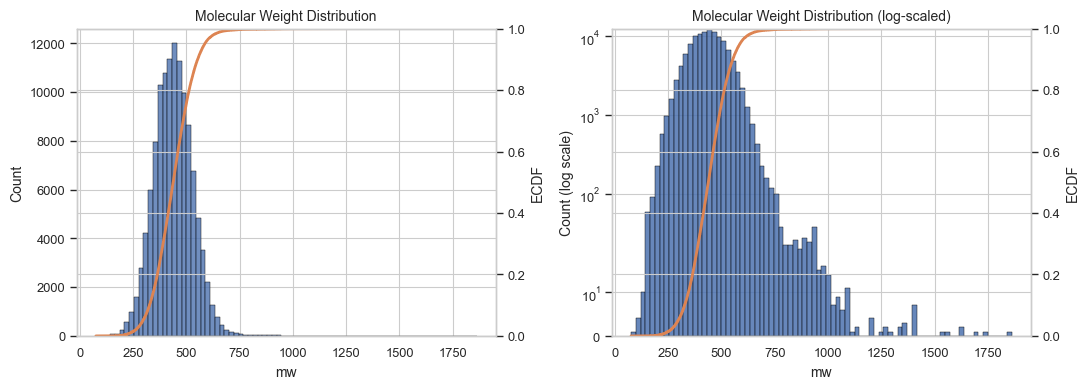

In [7]:
plot_dist_with_log(mws, "mw", title="Molecular Weight Distribution", show_ecdf=True)

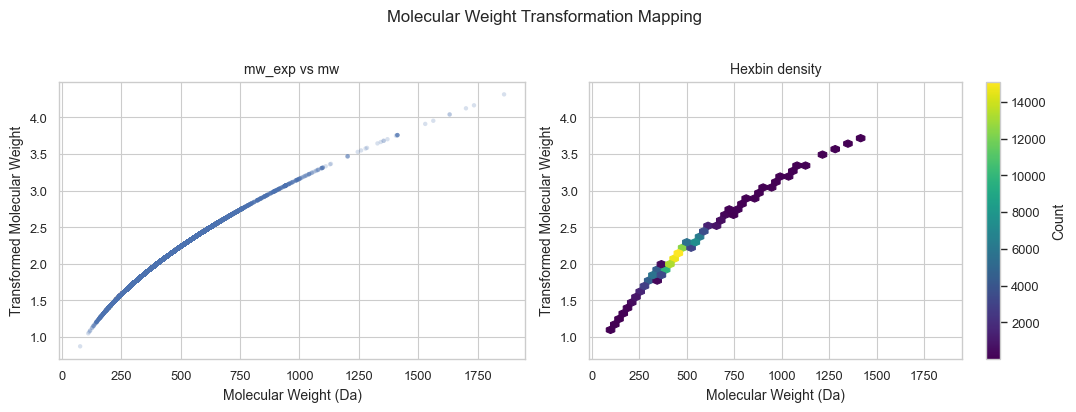

In [9]:
plot_transformation_mapping(mws, "mw", "mw_exp", title="Molecular Weight Transformation Mapping",
                            x_label="Molecular Weight (Da)",
                            y_label="Transformed Molecular Weight",
                            save_path=intr_helper_dir / "mw_transformation_mapping.png",
                            add_binned_trend=False,
                            kde_contour=False,)

# Transforms

## H-bonds
What PLIP does:
- Donor–acceptor distance $d_{DA}$ is $≤ 4.1 Å$ `(HBOND_DIST_MAX = 4.1)`
- Donor angle $∠(D−H⋯A)$ is $≥ 100°$ `(HBOND_DON_ANGLE_MIN = 100)`
- If the same groups already form a salt bridge, PLIP removes the overlapping hydrogen bond(s) (to avoid double-reporting)
- A donor is restricted to one H-bond; if multiple acceptors are possible, PLIP keeps the one whose $∠(D−H⋯A)$ is closest to $180°$. Acceptors can still participate in multiple bonds (bifurcated cases).

Let's define:

$\colorbox{orange}{This is the old version and it's wrong!}$

**Q**: a quality score that does not change too abruptly near the geometric thresholds, using a smooth logistic formulation to do this and to keep it in $[0,1]$:
$$
s_\theta = \sigma\!\left(\frac{d_{\max} - d}{\lambda_d}\right) \text{, and } s_d = \sigma\!\left(\frac{\theta - \theta_{\min}}{\lambda_\theta}\right)
$$
$$ 
Q = s_\theta \cdot s_d
$$

where the logistic (sigmoid) function is defined as:
$$ \sigma(x) = \frac{1}{1 + e^{-x}} $$

**Parameters:**

- $ d $: donor–acceptor distance (Å)  
- $ \theta $: donor–acceptor angle (degrees)  
- $ d_{\max} $: maximum distance cutoff (e.g. 4.1 Å in PLIP)  
- $ \theta_{\min} $: minimum angle cutoff (e.g. 100° in PLIP)  
- $ \lambda_d $: controls how fast the distance contribution ramps  
  (here **0.2–0.4 Å**)  
- $ \lambda_\theta $: controls angular softness  
  (here **5–15°**)  

The resulting score $Q \in (0,1)$, with higher values corresponding to shorter and more linear hydrogen bonds.

$\colorbox{yellowgreen}{The new version:}$

The relationship between the strength of the bond and angle and distance is so:
The stronger the bond, when:
- The more the angle is close to 180
- The less the distance


**So, we can say:**
$$
Q \propto \frac{\cos(∠(D−H⋯A))}{d_{DA}}  
$$

In [37]:
hydrogen_bonds_df.head()

,RESNR,RESTYPE,RESCHAIN,RESNR_LIG,RESTYPE_LIG,RESCHAIN_LIG,SIDECHAIN,DIST_H-A,DIST_D-A,DON_ANGLE,PROTISDON,DONORIDX,DONORTYPE,ACCEPTORIDX,ACCEPTORTYPE,LIGCOO,PROTCOO,activity_id
0,48,LEU,A,1,UNL,Z,False,1.79,2.69,151.89,False,1455,Npl,789,O2,"(-1.477, 18.513, 44.666)","(-3.405, 19.71, 46.118)",23227035
1,48,LEU,A,1,UNL,Z,False,1.92,2.90,162.57,True,784,Nam,1450,Nar,"(-0.942, 20.548, 43.637)","(-2.308, 22.328, 45.472)",23227035
2,52,SER,A,1,UNL,Z,False,2.03,2.96,151.87,True,845,Nam,1456,O2,"(-3.751, 12.62, 44.282)","(-4.813, 14.725, 42.494)",23227035
3,45,THR,A,1,UNL,Z,True,1.67,2.53,146.08,True,735,O3,1434,O2,"(1.909, 21.593, 40.698)","(3.132, 23.547, 41.736)",2111945
4,48,MET,A,1,UNL,Z,False,2.07,2.78,127.30,False,1432,Npl,782,O2,"(-1.082, 18.606, 45.341)","(-3.599, 19.474, 46.129)",2111945


- The column to use as $d$ is `DIST_D-A` $\rightarrow$ do I wanna incorporate `DIST_H-A` too? How? A weighted sum maybe?
- The column to use as $\theta$ is `DON_ANGLE`

## Angle

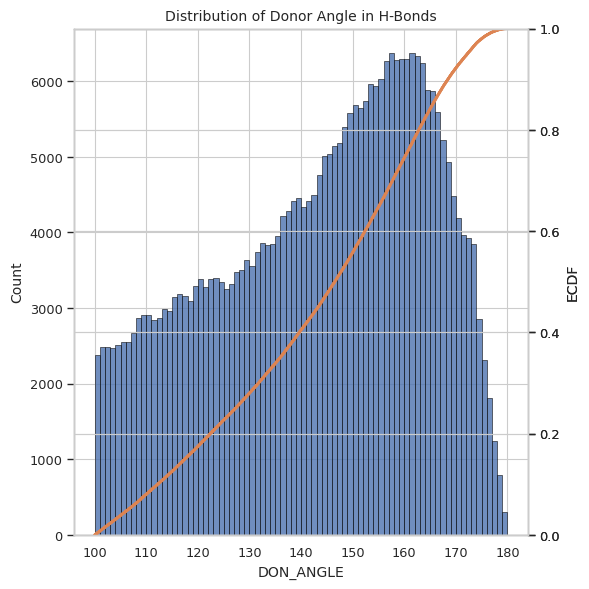

In [ ]:
plot_dist_with_log(hydrogen_bonds_df, "DON_ANGLE", title = "Distribution of Donor Angle in H-Bonds", show_ecdf=True, save_path=intr_helper_dir / "donor_angle_distribution.png", show_log_y=False)

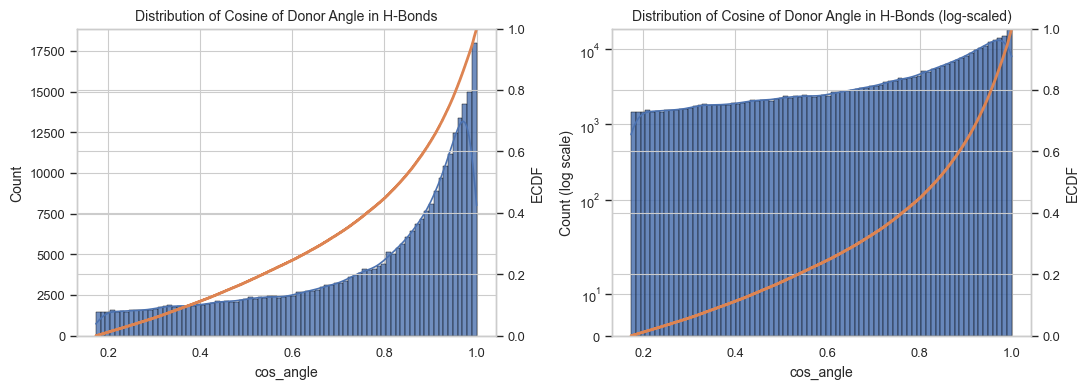

count    322499.000000
mean          0.752999
std           0.227277
min           0.173648
25%           0.605711
50%           0.834271
75%           0.941412
max           1.000000
Name: cos_angle, dtype: float64


In [21]:
# calculate cosine of donor angle for hydrogen bonds (we take the negative cosine to have a direct relationship with bond strength)
hydrogen_bonds_df["cos_angle"] = -np.cos(
    np.deg2rad(hydrogen_bonds_df["DON_ANGLE"])
)

plot_dist_with_log(hydrogen_bonds_df, col = "cos_angle", title = "Distribution of Cosine of Donor Angle in H-Bonds", kde=True, show_ecdf=True, )
                    # save_path=intr_helper_dir/"cos_angle_dist_hbond.png")
print(hydrogen_bonds_df["cos_angle"].describe())

## Distance

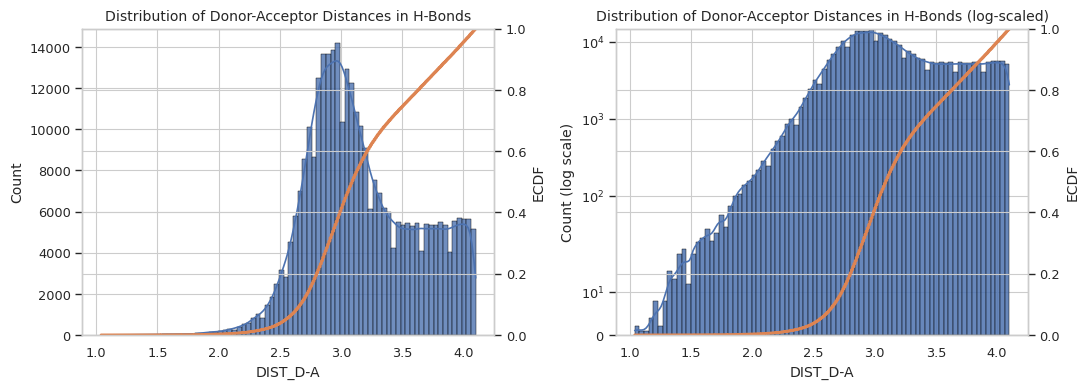

Mode: 2.99


count    322499.000000
mean          3.176407
std           0.448455
min           1.040000
25%           2.850000
50%           3.090000
75%           3.510000
max           4.100000
Name: DIST_D-A, dtype: float64

In [ ]:
plot_dist_with_log(hydrogen_bonds_df, col = "DIST_D-A", title = "Distribution of Donor-Acceptor Distances in H-Bonds", kde=True, show_ecdf=True, 
                    save_path=intr_helper_dir/"d_a_dist_hbond.png")
print(f"Mode: {hydrogen_bonds_df['DIST_D-A'].mode()[0]}")
hydrogen_bonds_df['DIST_D-A'].describe()

In [5]:
# Defaults
D_MAX = 4.1        # Å based on PLIP documentation
THETA_MIN = 100.0  # degrees
lam_theta_min = 90.0  # degrees
lam_theta_max = 150.0  # degrees
lam_d_min = 2.4  # Å
lam_d_max = 4.4  # Å 

In [19]:
hydrogen_bonds_df["DIST_D-A"].mode()

0    2.99
Name: DIST_D-A, dtype: float64

### Sigmoid

w = -0.624 Å
d_mid = 0.829 Å


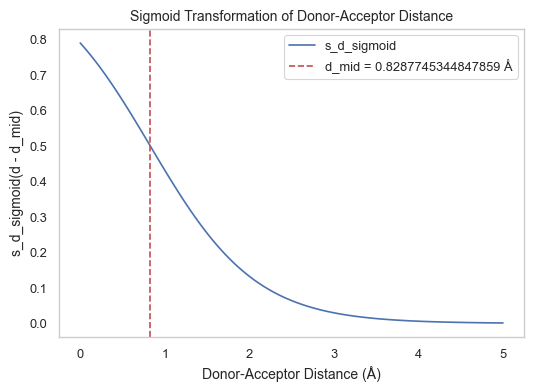

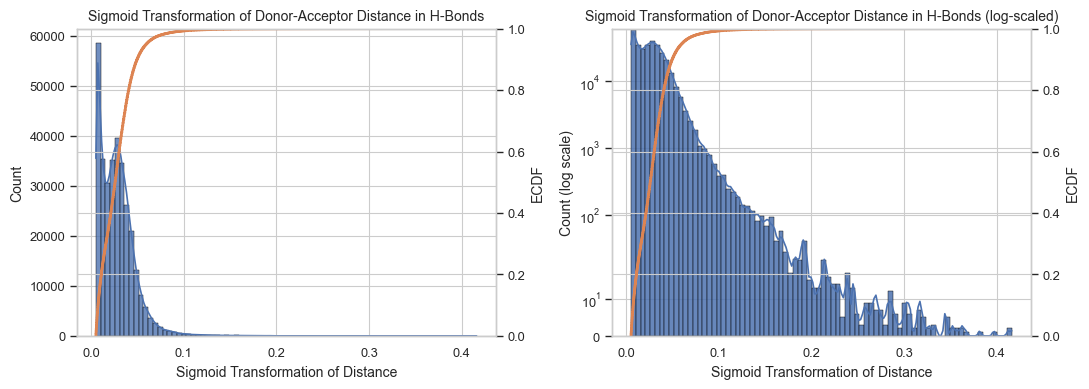

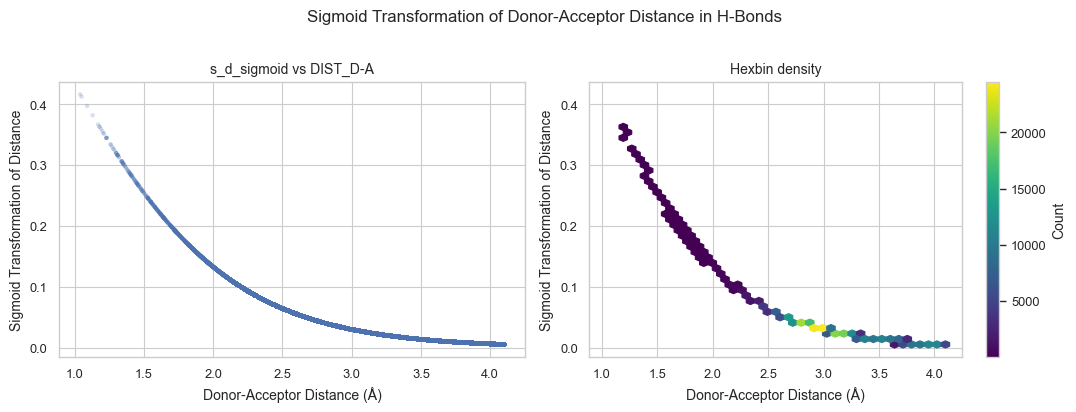

In [ ]:
# s(2.8 Å) = 0.9 (near-ideal N/O···N/O) and s(4.1 Å) = 0.3 (PLIP's HBOND_DIST_MAX).
d_mod = 2.2
p_mod = 0.9
d_max = 4.1
p_max = 0.3

logit = lambda p: np.log(p / (1 - p))
w  = -(d_max - d_mod) / (logit(p_max) - logit(p_mod))
print(f"w = {w:.3f} Å")
d_mid = d_mod + w*logit(p_mod)
print(f"d_mid = {d_mid:.3f} Å")

# s_d_hyperbolictan = lambda d: np.tanh((d - d_mid) / w)
s_d_sigmoid = lambda d: 1 / (1 + np.exp((d - d_mid) / w))

# plot the sigmoid itself and put a dot where d_mid and w are
d_values = np.linspace(0, 5, 100)
plt.figure(figsize=(6, 4))
plt.plot(d_values, s_d_sigmoid(d_values), label="s_d_sigmoid")
plt.xlabel("Donor-Acceptor Distance (Å)")
plt.ylabel("s_d_sigmoid(d - d_mid)")
plt.title("Sigmoid Transformation of Donor-Acceptor Distance")
plt.axvline(d_mid, color='r', linestyle='--', label=f"d_mid = {d_mid} Å")
plt.legend()
plt.grid()
plt.savefig(intr_helper_dir/"sigmoid_da_dist_hbond.png", dpi=300)

d = hydrogen_bonds_df["DIST_D-A"].to_numpy(dtype=float)
hydrogen_bonds_df["s_d_sigmoid"] = s_d_sigmoid(d)

plot_dist_with_log(hydrogen_bonds_df, col = "s_d_sigmoid", title = "Sigmoid Transformation of Donor-Acceptor Distance in H-Bonds",
                    x_label = "Sigmoid Transformation of Distance", 
                    kde=True, show_ecdf=True,
                    # save_path=intr_helper_dir/"sigmoid_da_dist_hbond.png"
                    )

plot_transformation_mapping(
    hydrogen_bonds_df,
    x_col = "DIST_D-A",
    y_col = "s_d_sigmoid", 
    x_label = "Donor-Acceptor Distance (Å)",
    y_label = "Sigmoid Transformation of Distance",
    add_binned_trend=False,
    kde_contour=False,
    title = "Sigmoid Transformation of Donor-Acceptor Distance in H-Bonds",
    # save_path=intr_helper_dir/"sigmoid_da_dist_hbond_mapping.png"
    )

### Gaussian

$\colorbox{yellow}{Thoughts on this: }$
Maybe it's better to penalize both tails, and assign best score to a ideal middle distance.

This can be modeled with a Gaussian, peaked around an ideal distance.

$$
s_d(d) = \exp(- \frac{(d-d^*)^2}{2\sigma^2})
$$

So the score would be 1 at $d=d^*$

The $\sigma$ would control the speed of the penalization. To pick $\sigma$, <br>
We choose:
- ideal donor–acceptor distance: $ d^* = 2.9\ \text{Å} $
- desired score at $ d = 4.0\ \text{Å} $: $ s_d(4.0) = 0.1 $

Substituting into the equation:

$$
0.1 = \exp\!\left(-\frac{(4.0 - 2.9)^2}{2\sigma^2}\right)
$$

Taking the natural logarithm:

$$
\ln(0.1) = -\frac{1.1^2}{2\sigma^2}
$$

Solving for \( \sigma \):

$$
\sigma^2 = \frac{1.1^2}{-2\ln(0.1)}
$$

$$
\sigma = \frac{1.1}{\sqrt{-2\ln(0.1)}} \approx 0.51\ \text{Å}
$$

Thus, choosing $ \sigma \approx 0.5\ \text{Å} $ yields a chemically reasonable distance score where
donor–acceptor distances near the cutoff ($\sim 4.0\ \text{Å}$) are assigned low but nonzero quality.


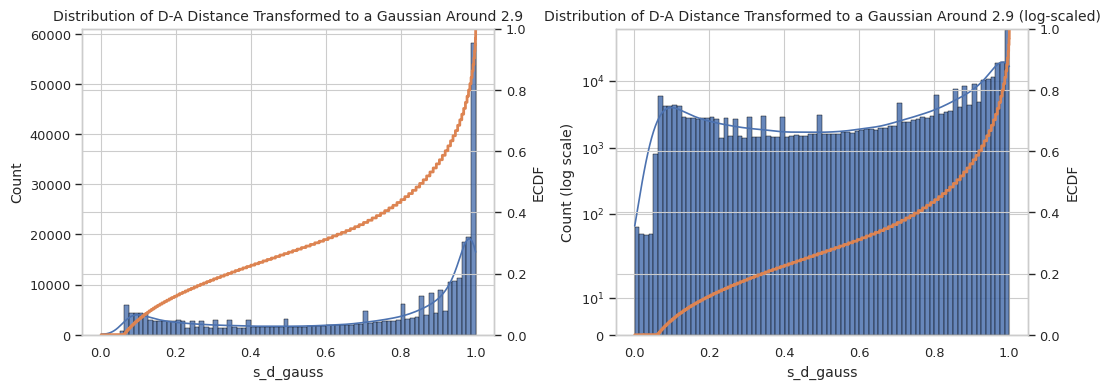

count    322499.000000
mean          0.709237
std           0.314231
min           0.001293
25%           0.455031
50%           0.860096
75%           0.972698
max           1.000000
Name: s_d_gauss, dtype: float64


In [ ]:
# d_star = hydrogen_bonds_df["DIST_D-A"].mode()[0]
d_star = 2.9
sigma = 0.51
score_min = 1.0   # tail floor (set >0)
score_max = 10.0  # ideal-distance score

d = hydrogen_bonds_df["DIST_D-A"].to_numpy(dtype=float)

hydrogen_bonds_df["s_d_gauss"] = np.exp(-((d - d_star) ** 2) / (2 * sigma ** 2))

plot_dist_with_log(hydrogen_bonds_df, col = "s_d_gauss", title = "Distribution of D-A Distance Transformed to a Gaussian Around 2.9"
                   , kde=True, show_ecdf=True,
                   save_path = intr_helper_dir/"s_d_gauss_dist_hbond.png")
print(hydrogen_bonds_df["s_d_gauss"].describe())


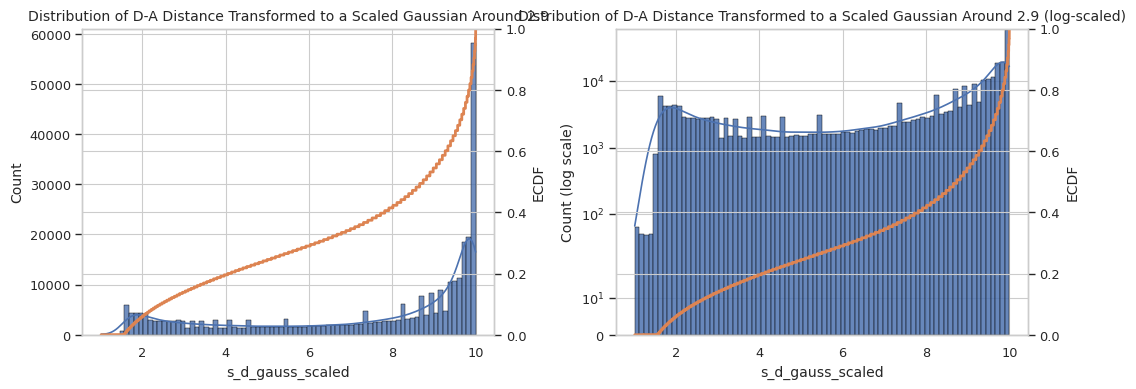

count    322499.000000
mean          7.383130
std           2.828076
min           1.011640
25%           5.095280
50%           8.740864
75%           9.754282
max          10.000000
Name: s_d_gauss_scaled, dtype: float64

In [ ]:
hydrogen_bonds_df["s_d_gauss_scaled"] = score_min + (score_max - score_min) * hydrogen_bonds_df["s_d_gauss"]
plot_dist_with_log(hydrogen_bonds_df, col = "s_d_gauss_scaled", title = "Distribution of D-A Distance Transformed to a Scaled Gaussian Around 2.9"
                   , kde=True, show_ecdf=True,)
hydrogen_bonds_df["s_d_gauss_scaled"].describe()

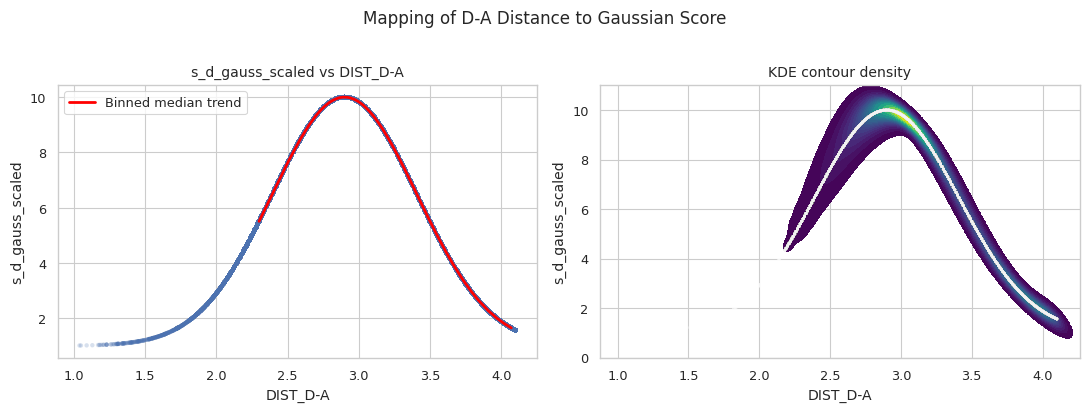

In [ ]:
from prob.prob_plots import plot_transformation_mapping



plot_transformation_mapping(hydrogen_bonds_df, x_col = "DIST_D-A", y_col="s_d_gauss_scaled", title = "Mapping of D-A Distance to Gaussian Score",
                            save_path=intr_helper_dir/"d_a_to_gaussian.png")

# Scores

## HB-Score, Sigmoid Distance Mapping

In [22]:
hydrogen_bonds_df["bond_score_sigmoid"] = (
    round(hydrogen_bonds_df["cos_angle"] * hydrogen_bonds_df["s_d_sigmoid"], 3)
)

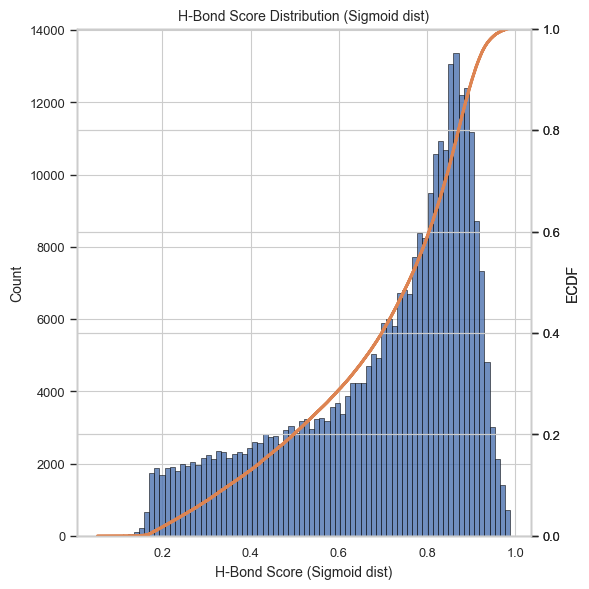

In [24]:
hydrogen_bonds_df["bond_score_sigmoid"].describe()

plot_dist_with_log(hydrogen_bonds_df, col="bond_score_sigmoid", 
                   x_label="H-Bond Score (Sigmoid dist)",
                   title="H-Bond Score Distribution (Sigmoid dist)", show_ecdf=True, show_log_y=False, 
                   save_path=intr_helper_dir/"hb_score_sigmoid_dist_no_mw.png")

## HB-Score, Gaussian Distance Mapping

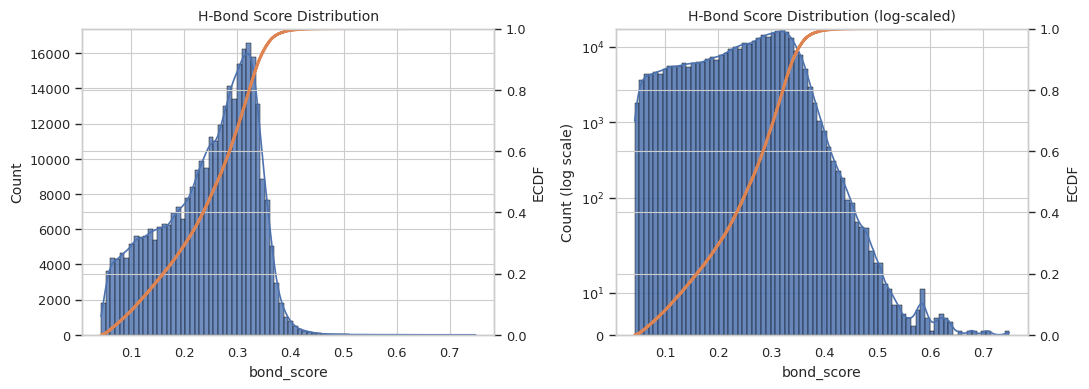

No Gaussian: count    322499.000000
mean          0.244523
std           0.086196
min           0.043000
25%           0.183000
50%           0.262000
75%           0.314000
max           0.749000
Name: bond_score, dtype: float64


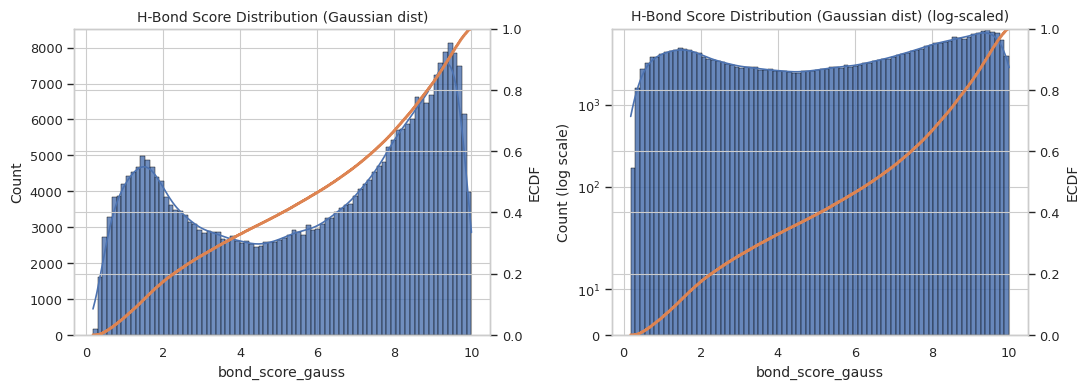

With Gaussian: count    322499.000000
mean          5.798683
std           3.009709
min           0.185000
25%           2.887000
50%           6.443000
75%           8.564000
max          10.000000
Name: bond_score_gauss, dtype: float64


In [ ]:
# Old score
# hydrogen_bonds_df["bond_score"] = (round(s_d(d = hydrogen_bonds_df["DIST_D-A"], lam_d = lam_d) *
#                                   s_theta(theta = hydrogen_bonds_df["DON_ANGLE"], lam_theta=lam_theta), 3))

# New score

hydrogen_bonds_df["bond_score"] = (round(hydrogen_bonds_df["cos_angle"] / hydrogen_bonds_df["DIST_D-A"], 3))
hydrogen_bonds_df["bond_score_gauss"] = (round(hydrogen_bonds_df["cos_angle"] * hydrogen_bonds_df["s_d_gauss_scaled"], 3))
# hydrogen_bonds_df[["DIST_D-A", "DON_ANGLE", "bond_score"]].head(10)
plot_dist_with_log(hydrogen_bonds_df, col = "bond_score", title="H-Bond Score Distribution", kde=True, show_ecdf=True, 
                    save_path = intr_helper_dir/"hbond_score_dist.png")
print(f"No Gaussian: {hydrogen_bonds_df['bond_score'].describe()}")


plot_dist_with_log(hydrogen_bonds_df, col = "bond_score_gauss", title="H-Bond Score Distribution (Gaussian dist)", kde=True, show_ecdf=True, 
                    save_path = intr_helper_dir/"hbond_score_gauss_dist.png")
print(f"With Gaussian: {hydrogen_bonds_df['bond_score_gauss'].describe()}")

# Aggregation per Complex

113453


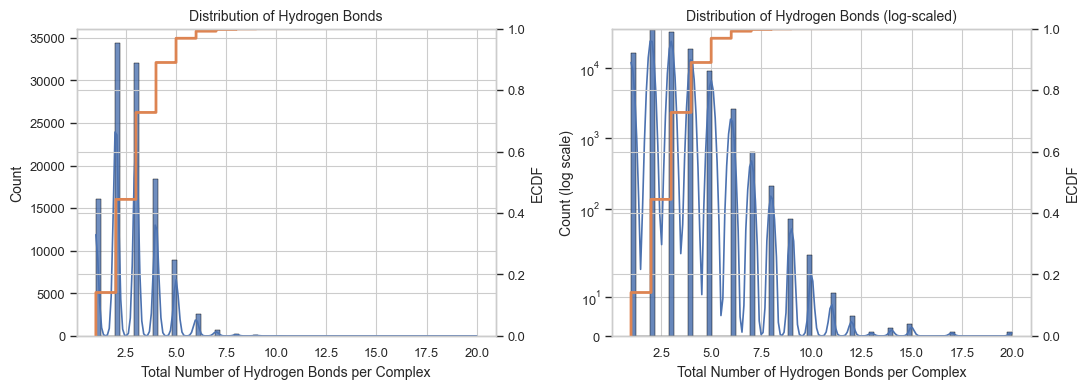

count    113453.000000
mean          2.842578
std           1.310509
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          20.000000
Name: num_h_bonds, dtype: float64


,activity_id,num_h_bonds,ident,y_processed
0,13302668,20,33827.0,5.148742
1,7808140,17,25008.0,6.425969
2,1097676,15,3102.0,8.585027
3,1090959,15,3069.0,8.136677
4,12688515,15,33006.0,4.853872


In [26]:
num_hydrogen_bonds = hydrogen_bonds_df['activity_id'].value_counts().reset_index(name='num_h_bonds')
# num_hydrogen_bonds = num_hydrogen_bonds.merge(mws, on='activity_id', how='right')
# num_hydrogen_bonds['weighted_num_hbs'] = (num_hydrogen_bonds['num_h_bonds'] * num_hydrogen_bonds['mw_weight'])
num_hydrogen_bonds = num_hydrogen_bonds.merge(mapping[['activity_id', 'ident', 'y_processed']], on='activity_id', how='left')

print(len(num_hydrogen_bonds))

plot_dist_with_log(num_hydrogen_bonds, col="num_h_bonds", 
                   x_label="Total Number of Hydrogen Bonds per Complex",
                   title="Distribution of Hydrogen Bonds", kde=True, show_ecdf=True, save_path=intr_helper_dir/"num_h_bonds_dist.png")
print(num_hydrogen_bonds["num_h_bonds"].describe())

num_hydrogen_bonds.head()

In [31]:
# bond_score_col = "bond_score_gauss"
bond_score_col = "bond_score_sigmoid"
# bond_score_col = "bond_score"

bond_scores = (
    hydrogen_bonds_df
    .groupby("activity_id", as_index=False)[bond_score_col]
    .sum()
)
bond_scores

,activity_id,bond_score_sigmoid
0,32335,0.409
1,32336,1.697
2,32680,2.746
3,32770,3.065
4,33033,1.438
...,...,...
113448,24970093,3.157
113449,24970094,3.105
113450,24970095,3.220
113451,24970104,3.199


## Normalize with Transformed MWs as Normalization Factor

In [32]:
bond_scores = bond_scores.merge(mws, on='activity_id', how='right').dropna(subset=[bond_score_col])
print(len(bond_scores))
bond_scores.head()

112559


,activity_id,bond_score_sigmoid,smiles,ident,y_processed,mw,mw_exp
0,32335,0.409,Nc1ncnc2c1c(-c1cccc(Oc3ccccc3)c1)cn2C1CCCC1,0,5.148742,370.456,1.924723
2,41979,1.693,c1ccc(Oc2ccc(Nc3ncnc4ccccc34)cc2)cc1,20,5.565431,313.360,1.770198
3,51886,1.664,Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)cn2[C@@H]1C[C...,44,6.568636,402.454,2.006126
4,443639,0.238,CC(C)(C)n1cc(-c2ccc(Oc3ccccc3)cc2)c2c(N)ncnc21,1221,5.640165,358.445,1.893264
5,447791,0.482,Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)c(C(=O)[O-])n...,1232,5.007889,413.457,2.033364


In [33]:
bond_scores['weighted_hb_score'] = (bond_scores[bond_score_col] / bond_scores['mw_exp'])
bond_scores.head()

,activity_id,bond_score_sigmoid,smiles,ident,y_processed,mw,mw_exp,weighted_hb_score
0,32335,0.409,Nc1ncnc2c1c(-c1cccc(Oc3ccccc3)c1)cn2C1CCCC1,0,5.148742,370.456,1.924723,0.212498
2,41979,1.693,c1ccc(Oc2ccc(Nc3ncnc4ccccc34)cc2)cc1,20,5.565431,313.360,1.770198,0.956390
3,51886,1.664,Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)cn2[C@@H]1C[C...,44,6.568636,402.454,2.006126,0.829460
4,443639,0.238,CC(C)(C)n1cc(-c2ccc(Oc3ccccc3)cc2)c2c(N)ncnc21,1221,5.640165,358.445,1.893264,0.125709
5,447791,0.482,Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)c(C(=O)[O-])n...,1232,5.007889,413.457,2.033364,0.237046


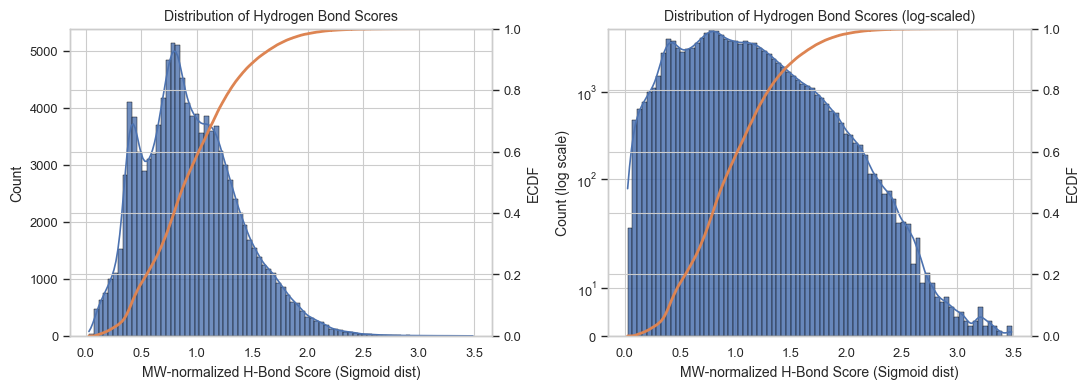

count    112559.000000
mean          0.945041
std           0.437664
min           0.028036
25%           0.626134
50%           0.894038
75%           1.217829
max           3.488266
Name: weighted_hb_score, dtype: float64


In [34]:
col = "weighted_hb_score"
# col = "sum_hb_score"
plot_dist_with_log(bond_scores, col=col, title = "Distribution of Hydrogen Bond Scores", 
                   x_label="MW-normalized H-Bond Score (Sigmoid dist)",
                   kde=True, show_ecdf=True, save_path=intr_helper_dir/"sum_hb_score_dist.png")
print(bond_scores[col].describe())

## Save Both Variants

In [35]:
from prob.paths_and_io import save_out_tensor

intr_name = "weighted_hb_score"
intr_df = bond_scores

interaction_dict = intr_df.set_index('ident')[intr_name].to_dict()
save_out_tensor(interaction_dict, output_dir = _ROOT/"data/probing/targets", filename = f"{intr_name}.pt")

PosixPath('/Users/fatemeh/Thesis/kinodata-3D-affinity-prediction/data/probing/targets/weighted_hb_score.pt')

Just to check:

In [16]:
from prob.paths_and_io import load_out_tensor

bond_scores = load_out_tensor(targets_dir, "hbond_score_no_mw.pt")
bond_scores = pd.DataFrame(list(bond_scores.items()), columns=['ident', 'hbond_score_no_mw'])
bond_scores.head()

,ident,hbond_score_no_mw
0,0,0.409
1,20,1.693
2,44,1.664
3,1221,0.238
4,1232,0.482


## Calculate Correlations

In [ ]:
from scipy.stats import linregress, spearmanr
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from prob.prob_plots import plot_joint_distribution

def compute_correlations(
    df: pd.DataFrame,
    bond_col: str,
    y_col: str = "y_processed",
) -> dict[str, float]:
    """Compute Pearson and Spearman correlations between number of bonds and affinity."""
    sub_df = df[[bond_col, y_col]].dropna()
    pearson = sub_df.corr(method="pearson").iloc[0, 1]
    spearman = sub_df.corr(method="spearman").iloc[0, 1]
    return {"pearson": pearson, "spearman": spearman}


def compute_bond_stats(
    df: pd.DataFrame,
    bond_col: str,
) -> dict[str, float]:
    """Compute basic statistics (mean, median, variance) for bond counts."""
    sub_series = df[bond_col].dropna()
    return {
        "mean": round(sub_series.mean(), 3),
        "median": round(sub_series.median(), 3),
        "variance": round(sub_series.var(), 3),
    }

# def plot_scatter_with_regression(
#     df: pd.DataFrame,
#     bond_col: str,
#     y_col: str = "y_processed",
#     *,
#     x_label: str | None = None,
#     y_label: str | None = None,
#     title: str | None = None,
#     dropna: bool = True,
#     cmap: str = "mako_r",
#     log_color: bool = True,
#     y_bins: int = 40,
#     save_dir: Path | None = None,
#     show: bool = True,
# ):
#     """Joint distribution of `bond_col` vs `y_col` with marginals, OLS fit and correlations."""
#     data = df[[bond_col, y_col]]
#     if dropna:
#         data = data.dropna()
#     x = data[bond_col].to_numpy(dtype=float)
#     y = data[y_col].to_numpy(dtype=float)

#     res = linregress(x, y)
#     rho = spearmanr(x, y).correlation

#     # integer-valued x -> one bin per count, centred on the integer
#     if np.allclose(x, np.round(x)):
#         x_bins = np.arange(x.min() - 0.5, x.max() + 1.5, 1.0)
#     else:
#         x_bins = y_bins

#     g = sns.JointGrid(data=data, x=bond_col, y=y_col, height=7, ratio=5, space=0.15)
#     g.figure.subplots_adjust(right=0.82)  # room for the colourbar

#     # joint: 2D histogram
#     *_, im = g.ax_joint.hist2d(
#         x, y, bins=[x_bins, y_bins], cmap=cmap, cmin=1,
#         norm=LogNorm() if log_color else None, rasterized=True,
#     )
#     g.ax_joint.grid(False)

#     # OLS fit
#     xs = np.array([x.min(), x.max()])
#     g.ax_joint.plot(xs, res.intercept + res.slope * xs, color="crimson", lw=2, label="OLS fit")
#     g.ax_joint.legend(loc="lower right", frameon=True)

#     # marginals
#     sns.histplot(x=x, bins=x_bins, stat="count", edgecolor="black", alpha=0.8, ax=g.ax_marg_x)
#     sns.histplot(y=y, bins=y_bins, stat="count", edgecolor="black", alpha=0.8, ax=g.ax_marg_y)
#     g.ax_marg_x.set_ylabel("Count")
#     g.ax_marg_y.set_xlabel("Count")
#     g.ax_marg_x.grid(False)
#     g.ax_marg_y.grid(False)

#     # stats box, top right
#     stats = (
#         f"n = {len(x):,}\n"
#         f"Pearson r = {res.rvalue:.3f}\n"
#         f"Spearman ρ = {rho:.3f}\n"
#         f"R² = {res.rvalue**2:.3f}"
#     )
#     g.ax_joint.text(
#         0.97, 0.97, stats, transform=g.ax_joint.transAxes, ha="right", va="top",
#         fontsize=10, bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="0.6"),
#     )

#     # colourbar outside, to the right
#     cax = g.figure.add_axes([0.86, 0.12, 0.025, 0.5])
#     cb = g.figure.colorbar(im, cax=cax)
#     cb.set_label("Count")

#     g.set_axis_labels(x_label or bond_col, y_label or y_col)
#     g.ax_marg_x.set_title(title or f"{y_col} vs {bond_col}")

#     if save_dir is not None:
#         g.figure.savefig(save_dir, dpi=300, bbox_inches="tight")
#     if show:
#         plt.show()
#     else:
#         plt.close(g.figure)
#     return {"pearson": res.rvalue, "spearman": rho, "r2": res.rvalue**2, "p": res.pvalue, "n": len(x)}

def plot_scatter_with_regression(
    df: pd.DataFrame, bond_col: str, y_col: str = "y_processed",
    hue: str = None,
    dropna: bool = True,
    use_hexbin: bool = True,
    title: str = None,):
    """ Scatter plot with regression line. """
    data = df[[bond_col, y_col] + ([hue] if hue else [])]
    
    if dropna:
        data = data.dropna()

    plt.figure(figsize=(6, 5))
    sns.regplot(
        data=data,
        x=bond_col,
        y=y_col,
        scatter_kws={"alpha": 0.2, "s": 10},
        line_kws={"color": "red"},
    )

    if title:
        plt.title(title)
    else:
        plt.title(f"{y_col} vs {bond_col}")

    plt.tight_layout()
    plt.show()

In [38]:
bond_scores.head()

,activity_id,bond_score_sigmoid,smiles,ident,y_processed,mw,mw_exp,weighted_hb_score
0,32335,0.409,Nc1ncnc2c1c(-c1cccc(Oc3ccccc3)c1)cn2C1CCCC1,0,5.148742,370.456,1.924723,0.212498
2,41979,1.693,c1ccc(Oc2ccc(Nc3ncnc4ccccc34)cc2)cc1,20,5.565431,313.360,1.770198,0.956390
3,51886,1.664,Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)cn2[C@@H]1C[C...,44,6.568636,402.454,2.006126,0.829460
4,443639,0.238,CC(C)(C)n1cc(-c2ccc(Oc3ccccc3)cc2)c2c(N)ncnc21,1221,5.640165,358.445,1.893264,0.125709
5,447791,0.482,Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)c(C(=O)[O-])n...,1232,5.007889,413.457,2.033364,0.237046


In [78]:
figures_dir 

PosixPath('/Users/fatemeh/Thesis/kinodata-3D-affinity-prediction/data/probing/targets/figures')

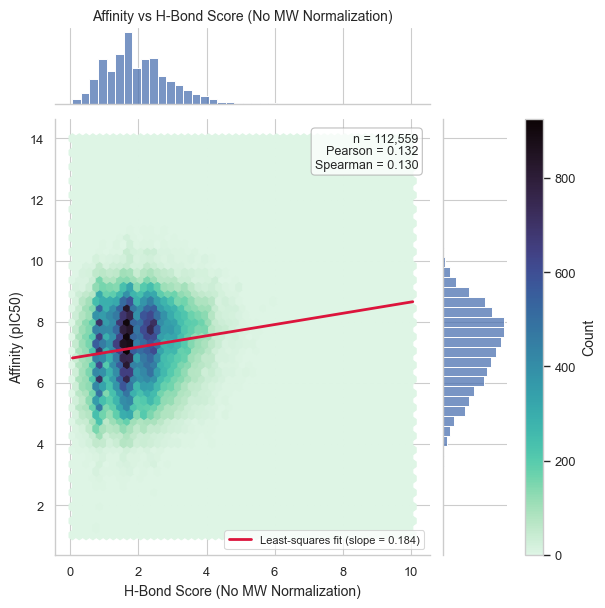

{'pearson': 0.13165502925564435, 'spearman': 0.1302409931070291, 'n': 112559}

In [79]:
plot_joint_distribution(bond_scores, x_col="bond_score_sigmoid", y_col="y_processed", 
                        kind="hex",
                        x_label="H-Bond Score (No MW Normalization)", y_label="Affinity (pIC50)", 
                        title="Affinity vs H-Bond Score (No MW Normalization)",
                        save_path=figures_dir/"hbond_score_no_mw_vs_affinity_hex.png")

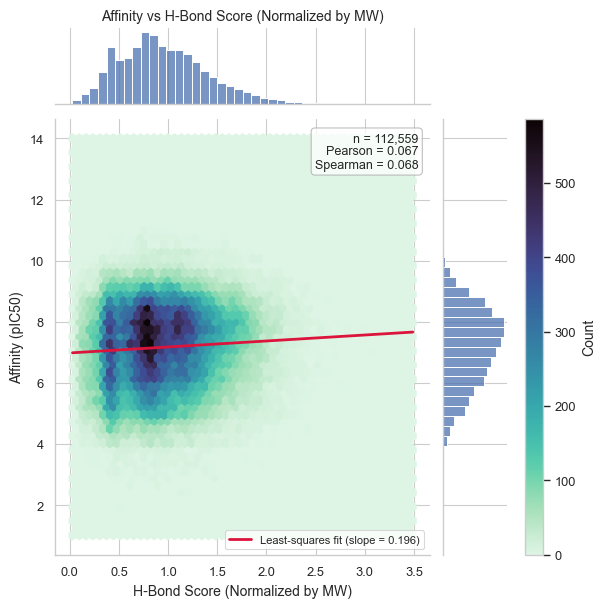

{'pearson': 0.06697733083239699, 'spearman': 0.068017226053632, 'n': 112559}

In [80]:
plot_joint_distribution(bond_scores, x_col="weighted_hb_score", y_col="y_processed", 
                        kind="hex",
                        x_label="H-Bond Score (Normalized by MW)", y_label="Affinity (pIC50)", 
                        title="Affinity vs H-Bond Score (Normalized by MW)",
                        save_path=figures_dir/"hbond_score_mw_normalised_vs_affinity_hex.png")

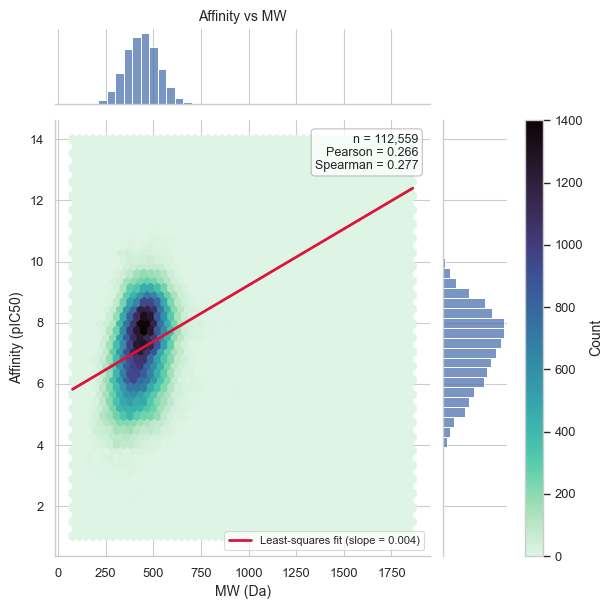

{'pearson': 0.2655270490978458, 'spearman': 0.27723210142681914, 'n': 112559}

In [81]:
plot_joint_distribution(bond_scores, x_col = "mw", y_col="y_processed", 
                        kind = "hex",
                        x_label="MW (Da)", y_label="Affinity (pIC50)", 
                        title="Affinity vs MW",
                        save_path=figures_dir/"mw_vs_affinity_hex.png")

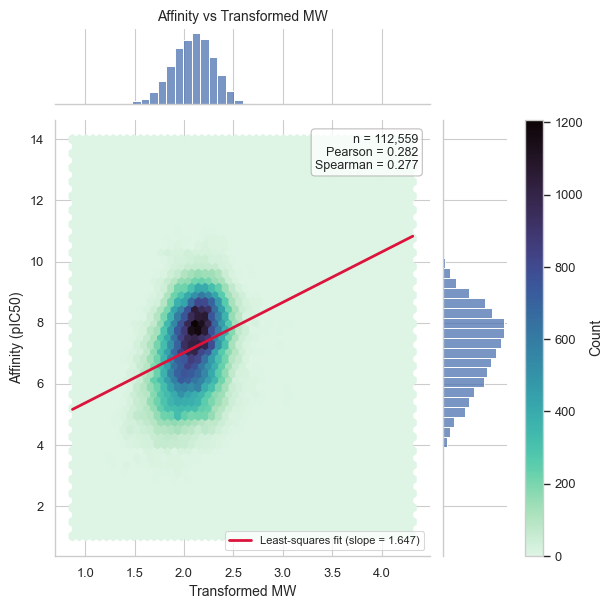

{'pearson': 0.28170782276259293, 'spearman': 0.2772317200636549, 'n': 112559}

In [82]:
plot_joint_distribution(bond_scores, x_col = "mw_exp", y_col="y_processed",
                        kind = "hex",
                        x_label="Transformed MW", y_label="Affinity (pIC50)",
                        title="Affinity vs Transformed MW",
                        save_path=figures_dir/"mw_exp_vs_affinity_hex.png")

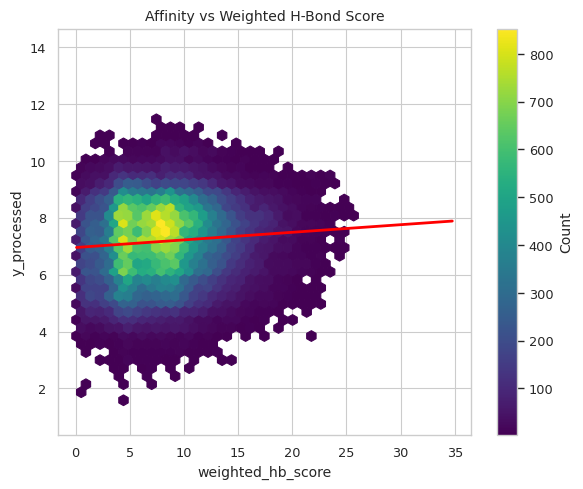

In [ ]:
from prob.prob_plots import scatter_affinity_vs_bonds

scatter_affinity_vs_bonds(bond_scores, bond_col="weighted_hb_score", title="Affinity vs Weighted H-Bond Score", save_path=figures_dir/"affinity_vs_weighted_hb_score.png")

In [ ]:
scatter_affinity_vs_bonds(num_hydrogen_bonds, bond_col="num_h_bonds", title="Affinity vs Number of H-Bonds", save_path=figures_dir/"affinity_vs_num_h_bonds.png")

NameError: name 'scatter_affinity_vs_bonds' is not defined


bond_score_sigmoid correlations: {'pearson': 0.13165502925564493, 'spearman': 0.1302409931070291}
stats: {'mean': 1.962, 'median': 1.806, 'variance': 0.835}
[Linear regression]
r^2       = 0.0173
p-value   = 0.00e+00



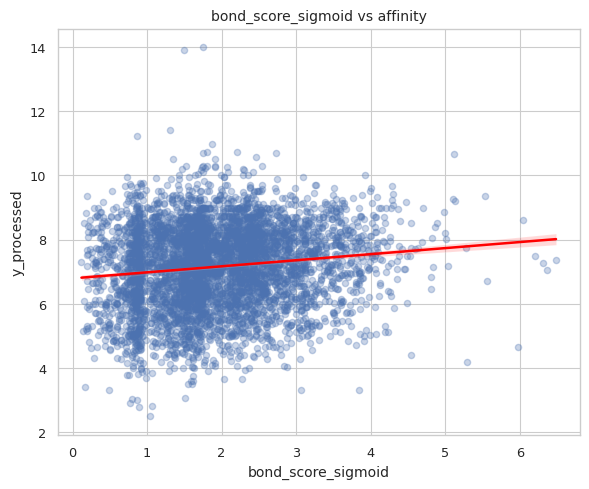

In [64]:
for intr_name, intr_df in interactions.items():
    corrs = compute_correlations(intr_df, bond_col=intr_name)
    print(f"\n{intr_name} correlations: {corrs}")
    print(f"stats: {compute_bond_stats(intr_df, bond_col=intr_name)}")
    plot_scatter_with_regression(
        intr_df,
        bond_col=intr_name,
        title=f"{intr_name} vs affinity",
        use_hexbin=False,
        # save_dir=figures_dir/f"scatter_{intr_name}_vs_affinity.png"
    )

# Hydrophobic interactions

In [47]:
hydrophobic_interactions_df = pd.read_csv(interactions_dir / "hydrophobic_interactions.csv")
hydrophobic_interactions_df.head()

,RESNR,RESTYPE,RESCHAIN,RESNR_LIG,RESTYPE_LIG,RESCHAIN_LIG,DIST,LIGCARBONIDX,PROTCARBONIDX,LIGCOO,PROTCOO,activity_id
0,3,LEU,A,1,UNL,Z,3.67,1429,50,"(-1.716, 16.737, 46.306)","(1.733, 16.043, 47.345)",23227035
1,11,VAL,A,1,UNL,Z,3.74,1433,150,"(1.081, 18.346, 40.738)","(4.321, 18.502, 42.597)",23227035
2,15,ALA,A,1,UNL,Z,3.97,1436,212,"(0.368, 20.526, 41.618)","(3.197, 22.165, 43.864)",23227035
3,36,VAL,A,1,UNL,Z,3.64,1448,579,"(1.026, 21.29, 40.525)","(-0.973, 24.295, 40.031)",23227035
4,47,TYR,A,1,UNL,Z,3.64,1429,777,"(-1.716, 16.737, 46.306)","(-0.036, 19.395, 48.146)",23227035


In [49]:
save_dir

PosixPath('/home/fatemeh/thesis/kinodata-3D-affinity-prediction/data/probing/helpers/intr_scores')

116478


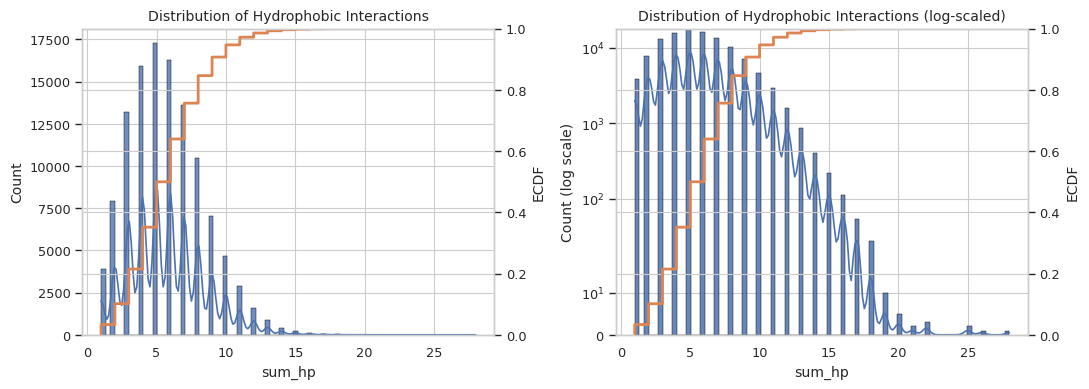

Hydrophobic interaction score stats:
count    116478.000000
mean          5.761045
std           2.706065
min           1.000000
25%           4.000000
50%           6.000000
75%           7.000000
max          28.000000
Name: sum_hp, dtype: float64


,activity_id,sum_hp,ident,y_processed
0,24708162,28,116268.0,8.000000
1,2044839,26,8619.0,4.640165
2,13302668,25,33827.0,5.148742
3,18201830,25,94517.0,7.950782
4,19071954,22,101669.0,5.158453


In [50]:
hydrophobic_intr_total = hydrophobic_interactions_df['activity_id'].value_counts().reset_index(name='sum_hp')
hydrophobic_intr_total = hydrophobic_intr_total.merge(mapping[['activity_id', 'ident', 'y_processed']], on='activity_id', how='left')

print(len(hydrophobic_intr_total))

plot_dist_with_log(hydrophobic_intr_total, col="sum_hp", title="Distribution of Hydrophobic Interactions", kde=True, show_ecdf=True, save_path=_DATA_DIR/"probing/targets/figures/hydrophobic_interactions_dist.png")

print(f"Hydrophobic interaction score stats:")
print(hydrophobic_intr_total["sum_hp"].describe())
hydrophobic_intr_total.head()


 sum_hp correlations: {'pearson': 0.03733411697029246, 'spearman': 0.03552944562515529}
stats: {'mean': 5.761, 'median': 6.0, 'variance': 7.323}
[Linear regression]
r^2       = 0.0014
p-value   = 6.19e-37



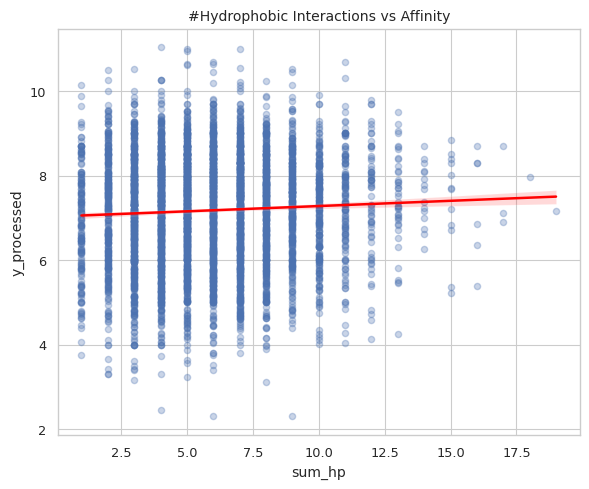

<Figure size 640x480 with 0 Axes>

In [ ]:
corrs = compute_correlations(hydrophobic_intr_total, bond_col="sum_hp")
print(f"\n sum_hp correlations: {corrs}")
print(f"stats: {compute_bond_stats(hydrophobic_intr_total, bond_col='sum_hp')}")
plot_scatter_with_regression(
    hydrophobic_intr_total,
    bond_col="sum_hp",
    title=f"#Hydrophobic Interactions vs Affinity",
    use_hexbin=False,
    save_dir=figures_dir/"scatter_sum_hp_vs_affinity.png"
)

In [ ]:
hp_dict = hydrophobic_intr_total.set_index('ident')["sum_hp"].to_dict()
save_out_tensor(hp_dict, output_dir = targets_dir, filename = f"sum_hp.pt")

PosixPath('/home/fatemeh/thesis/kinodata-3D-affinity-prediction/data/probing/targets/sum_hp.pt')